In [6]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import resample


In [464]:
import pandas as pd
import re

def clean_prediction(text):
    """
    Cleans age prediction text and returns a comma-separated string of unique age expressions
    in the original order (no sorting).
    - Converts 'X weeks to Y weeks' → 'X-Y weeks'
    - Removes spaces around hyphens in ranges: 'X - Y' → 'X-Y'
    - Removes weight-related entries (e.g., '200-300 g', '350 grams')
    - Filters out non-specific labels when specific ones are present
    - If nothing valid remains, returns 'age not specified'
    - Preserves input order
    """
    if pd.isna(text):
        return "age not specified"

    text = text.replace('\n', ' ').replace('\t', ' ')

    # Extract AGE: segments
    matches = re.findall(r'AGE:\s*(.*?)(?=\s*(AGE:|$|###|---))', text, flags=re.IGNORECASE)

    extracted_parts = []
    for match, _ in matches:
        match = match.strip()
        match = re.sub(r'\s+and\s+', ', ', match, flags=re.IGNORECASE)
        match = re.sub(r'(\d+)\s*(weeks?|months?|days?|years?)\s+to\s+(\d+)\s*(weeks?|months?|days?|years?)',
                       lambda m: f"{m.group(1)}-{m.group(3)} {m.group(2)}", match, flags=re.IGNORECASE)
        match = re.sub(r'(\d+)\s+to\s+(\d+)', r'\1-\2', match, flags=re.IGNORECASE)
        match = re.sub(r'\s*-\s*', '-', match)  # normalize hyphens
        extracted_parts.extend([m.strip() for m in match.split(',')])

    if not matches:
        text = text.strip()
        text = re.sub(r'\s+and\s+', ', ', text, flags=re.IGNORECASE)
        text = re.sub(r'(\d+)\s*(weeks?|months?|days?|years?)\s+to\s+(\d+)\s*(weeks?|months?|days?|years?)',
                      lambda m: f"{m.group(1)}-{m.group(3)} {m.group(2)}", text, flags=re.IGNORECASE)
        text = re.sub(r'(\d+)\s+to\s+(\d+)', r'\1-\2', text, flags=re.IGNORECASE)
        text = re.sub(r'\s*-\s*', '-', text)
        extracted_parts = [m.strip() for m in text.split(',')]

    # Remove weight-related expressions (e.g., 300-350 g, 200 grams, 0.5 kg)
    weight_pattern = re.compile(r'\b\d*\.?\d+\s*[-–]?\s*\d*\s*(g|gram|grams|kg|kilogram|kilograms)\b', re.IGNORECASE)
    extracted_parts = [p for p in extracted_parts if not weight_pattern.search(p)]

    # Remove empty strings and normalize
    extracted_parts = [p for p in extracted_parts if p.strip()]

    # Handle non-specific age expressions
    nonspecific_pattern = re.compile(r'^(age\s*)?(not specified|unknown|unspecified)$', re.IGNORECASE)
    specific = [p for p in extracted_parts if not nonspecific_pattern.fullmatch(p)]
    nonspecific = [p for p in extracted_parts if nonspecific_pattern.fullmatch(p)]

    seen = set()
    def unique_ordered(items):
        for item in items:
            if item not in seen:
                seen.add(item)
                yield item

    if not specific and nonspecific:
        return ', '.join(unique_ordered(nonspecific))
    elif not specific:
        return "age not specified"

    return ', '.join(unique_ordered(specific))


In [430]:
def bootstrap_metric(y_true, y_pred, metric_func, n_iterations=1000, ci=95):
    """
    Bootstraps a metric to compute mean and confidence interval.

    Returns:
        mean, (lower_ci, upper_ci)
    """
    scores = []
    n = len(y_true)
    for _ in range(n_iterations):
        indices = np.random.choice(n, n, replace=True)
        score = metric_func(y_true[indices], y_pred[indices])
        scores.append(score)

    lower = np.percentile(scores, (100 - ci) / 2)
    upper = np.percentile(scores, 100 - (100 - ci) / 2)
    return np.mean(scores), (lower, upper)

def evaluate_predictions(df, prediction_col='prediction_clean', target_col='target'):
    """
    Evaluate model predictions by comparing cleaned prediction outputs against ground-truth targets.

    This function merges predictions with targets, normalizes the text (lowercasing, trimming),
    computes accuracy, precision, recall, and F1, and returns error rows and confidence intervals.
    """

    def normalize_label(text):
        parts = [part.strip().lower() for part in str(text).split(',')]
        parts = list(dict.fromkeys(parts))  # remove duplicates, preserve order
        return ', '.join(sorted(parts))  # sort for comparison

    # Apply normalization
    y_true = df[target_col].apply(normalize_label)
    y_pred = df[prediction_col].apply(normalize_label)
    
    y_true_np = y_true.to_numpy()
    y_pred_np = y_pred.to_numpy()

    # Main metrics
    accuracy = accuracy_score(y_true_np, y_pred_np)
    precision = precision_score(y_true_np, y_pred_np, average='micro', zero_division=0)
    recall = recall_score(y_true_np, y_pred_np, average='micro', zero_division=0)
    f1 = f1_score(y_true_np, y_pred_np, average='micro', zero_division=0)

    # Confidence intervals
    accuracy_boot, accuracy_ci = bootstrap_metric(y_true_np, y_pred_np, accuracy_score)
    f1_boot, f1_ci = bootstrap_metric(y_true_np, y_pred_np, lambda yt, yp: f1_score(yt, yp, average='micro', zero_division=0))

    # Error analysis
    error_mask = y_true != y_pred
    error_df = df[error_mask].copy()
    error_df['target_clean'] = y_true
    error_df['prediction_clean_normalized'] = y_pred
    error_df['error_type'] = 'mismatch'
    print(f"Found {error_df.shape[0]} mismatches")

    results = {
        'accuracy': accuracy,
        'accuracy_ci': accuracy_ci,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'f1_ci': f1_ci
    }
    # Round all numeric values or each element of tuple values
    def round_value(v):
        if isinstance(v, tuple):
            return tuple(round(x, 4) for x in v)
        return round(v, 4)
    
    results = {k: round_value(v) for k, v in results.items()}
    return results, error_df

### Load Targets

In [13]:
targets_df = pd.read_csv("./clean_annotations/age_standardized.csv")
target_col = targets_df[['doc_id_unique','target']]
target_col['target'] = (
    target_col['target']
    .str.replace(r'\s+', ' ', regex=True)  # Replace all whitespace (including \n) with a single space
    .str.strip()                           # Remove leading/trailing spaces
)
print(target_col.shape)
target_col.head()


(486, 2)


/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_19193/576057187.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_col['target'] = (


,doc_id_unique,target
0,My_pdf69new_method_34_219,10-13 weeks
1,My_pdf764_method_46_295,adult
2,My_pdf484new_method_1068_1157,0-10 days
3,My_pdf238new_method_28_219,adult
4,My_pdf737_method_47_178,"10-12 weeks, 5 days"


# Eval Models

In [173]:
def process_model_predictions(
    predictions_df,
    targets_df,
    model_name_str="age_deepseek_r1_distill_llama_8b_all",
    error_output_folder="model_errors",
    prediction_col="age_prediction",
    target_col="target_clean",
    clean_func=None,
    eval_func=None
):
    """
    Load, clean, evaluate, and save model predictions.
    """
    import os

    # Load model predictions
    df = predictions_df
    print(f"{model_name_str}: Loaded {df.shape[0]} rows.")

    # Clean predictions
    if clean_func:
        df['prediction_clean'] = df[prediction_col].apply(clean_func)

    # Evaluate predictions
    if eval_func:
        # Merge predictions with targets
        df = pd.merge(predictions_df, targets_df, on='doc_id_unique', how='left')
        nan_count = df[target_col].isna().sum()
        print(f"Number of NaN values in 'target_clean' before filling: {nan_count}")

        # Fill missing target values with "AGE NOT SPECIFIED"
        df[target_col] = df[target_col].fillna("AGE NOT SPECIFIED")
        print(f"Evaluating {df.shape[0]} merged rows")

        results, error_df = eval_func(df, prediction_col='prediction_clean', target_col=target_col)

        # Save errors
        os.makedirs(error_output_folder, exist_ok=True)
        error_file = os.path.join(error_output_folder, f"{model_name_str}_errors.csv")
        error_df[['doc_id_unique', 'target_clean', 'prediction_clean_normalized']].to_csv(error_file, index=False)
        print(f"Saved errors to: {error_file}")

        # Save a random sample of 10 errors
        sample_file = os.path.join(error_output_folder, f"{model_name_str}_errors_sample10.csv")
        error_df[['doc_id_unique', 'target_clean', 'prediction_clean_normalized']].sample(n=10, random_state=42).to_csv(sample_file, index=False)
        print(f"Saved random sample of 10 errors to: {sample_file}")

        return results, error_df

    return df

In [379]:
def plot_model_metric_with_ci(
    results_list,
    model_names,
    metric='accuracy',
    annotation_type="age",
    save_dir="viz"
):
    """
    Plot model metric (accuracy or F1) with 95% CI using colored dots, larger size, and value labels.

    Parameters:
    - results_list: List of dicts from evaluate_predictions
    - model_names: List of model names (x-axis labels)
    - metric: 'accuracy' or 'f1_score'
    - annotation_type: For title/filename
    - save_dir: Folder to save plot
    """

    assert metric in ['accuracy', 'f1_score'], "Metric must be 'accuracy' or 'f1_score'"

    # Prepare data
    metric_vals = []
    ci_lows = []
    ci_highs = []

    for res in results_list:
        val = res[metric]
        ci_low, ci_high = res[f"{metric}_ci"]
        metric_vals.append(val)
        ci_lows.append(val - ci_low)
        ci_highs.append(ci_high - val)

    x_pos = range(len(model_names))
    colors = plt.cm.Set2.colors[:len(model_names)]  # get distinct colors

    # Plot
    plt.figure(figsize=(6, 5))
    for i, (x, y, low, high, color) in enumerate(zip(x_pos, metric_vals, ci_lows, ci_highs, colors)):
        # Error bar
        plt.errorbar(
            x=x,
            y=y,
            yerr=[[low], [high]],
            fmt='o',
            capsize=6,
            markersize=8,
            color=color,
            ecolor='gray',
            elinewidth=2,
            markerfacecolor=color
        )

        # Add value label
        plt.text(
            x, y + 0.03, f"{y:.2f}",
            ha='center',
            va='bottom',
            fontsize=11,
            color=color,
            weight='bold'
        )

    # Axis setup
    plt.xticks(ticks=x_pos, labels=model_names, rotation=15, fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylabel(metric.title(), fontsize=13)
    plt.xlabel("Model", fontsize=13)
    plt.title(f"{metric.title()} with 95% CI ({annotation_type})", fontsize=15)
    plt.ylim(0, 1.05)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Save
    os.makedirs(save_dir, exist_ok=True)
    filename = f"model_{metric}_with_ci_{annotation_type}.png"
    plt.tight_layout()
    print(f'saving to {os.path.join(save_dir, filename)}')
    plt.savefig(os.path.join(save_dir, filename))
    plt.show()

## Age

In [382]:
model_file_name = "age_deepseek-r1-distill-llama-8b_all.csv"
predictions_df_1 = pd.read_csv(f"./model_predictions/age/{model_file_name}")
model_name_str = model_file_name.replace(".csv", "").replace("-", "_")
results_1, _ = process_model_predictions(
    predictions_df=predictions_df,
    targets_df=targets_df,
    model_name_str=model_name_str,
    prediction_col="age_prediction",
    target_col="target",
    clean_func=clean_prediction,
    eval_func=evaluate_predictions
)

model_file_name = "age_meta-llama-3.1-8b_instruct_v2_all.csv"
predictions_df_2 = pd.read_csv(f"./model_predictions/age/{model_file_name}")
model_name_str = model_file_name.replace(".csv", "").replace("-", "_")
results_2, _ = process_model_predictions(
    predictions_df=predictions_df,
    targets_df=targets_df,
    model_name_str=model_name_str,
    prediction_col="age_prediction",
    target_col="target",
    clean_func=clean_prediction,
    eval_func=evaluate_predictions
)


age_deepseek_r1_distill_llama_8b_all: Loaded 3009 rows.
Number of NaN values in 'target_clean' before filling: 3009
Evaluating 3009 merged rows
Found 3009 mismatches
Saved errors to: model_errors/age_deepseek_r1_distill_llama_8b_all_errors.csv
Saved random sample of 10 errors to: model_errors/age_deepseek_r1_distill_llama_8b_all_errors_sample10.csv
age_meta_llama_3.1_8b_instruct_v2_all: Loaded 3009 rows.
Number of NaN values in 'target_clean' before filling: 3009
Evaluating 3009 merged rows
Found 3009 mismatches
Saved errors to: model_errors/age_meta_llama_3.1_8b_instruct_v2_all_errors.csv
Saved random sample of 10 errors to: model_errors/age_meta_llama_3.1_8b_instruct_v2_all_errors_sample10.csv


In [36]:
results_1

{'accuracy': 0.9403292181069959,
 'accuracy_ci': (0.9176954732510288, 0.9588477366255144),
 'precision': 0.9403292181069959,
 'recall': 0.9403292181069959,
 'f1_score': 0.9403292181069959,
 'f1_ci': (0.9176954732510288, 0.9609053497942387)}

In [38]:
results_2

{'accuracy': 0.9403292181069959,
 'accuracy_ci': (0.919701646090535, 0.9588991769547325),
 'precision': 0.9403292181069959,
 'recall': 0.9403292181069959,
 'f1_score': 0.9403292181069959,
 'f1_ci': (0.9176954732510288, 0.9609053497942387)}

saving to viz/model_accuracy_with_ci_Age.png


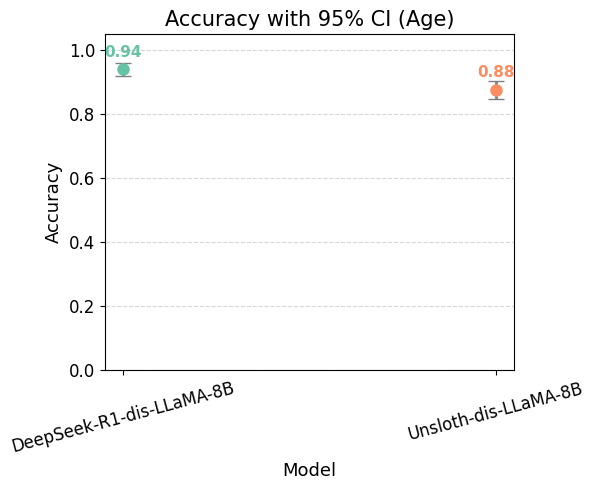

In [400]:
plot_model_metric_with_ci(
    results_list=[results_1, results_2],
    model_names=["DeepSeek-R1-dis-LLaMA-8B", "Unsloth-dis-LLaMA-8B"],
    metric="accuracy",  # or "accuracy"
    annotation_type="Age"
)

## On Full Methods

In [280]:
# Load and clean
targets_df = pd.read_csv("./clean_annotations/age_standardized.csv")
targets_df = targets_df[['doc_id_unique', 'target']]

# Normalize whitespace
targets_df['target'] = (
    targets_df['target']
    .astype(str)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Clean trailing _number_number pattern from doc_id_unique
targets_df['doc_id_unique'] = targets_df['doc_id_unique'].str.replace(r'_\d+_\d+$', '', regex=True)

# Group by doc_id_unique and merge unique targets
def merge_unique_targets(group):
    unique_targets = list(dict.fromkeys(group.dropna()))  # preserve order, remove duplicates
    return ', '.join(unique_targets)

targets_df = (
    targets_df
    .groupby('doc_id_unique', as_index=False)
    .agg({'target': merge_unique_targets})
)

print(targets_df.shape)
targets_df.head()

(422, 2)


,doc_id_unique,target
0,My_pdf102new_method,6-12 weeks
1,My_pdf103new_method,13 days
2,My_pdf103new_title^abstract,adult
3,My_pdf105new_method,8-9 weeks
4,My_pdf10new_method,adult


In [294]:
model_file_name = "age_deepseek-r1-distill-llama-8b_task_specific_prompt.csv"
predictions_df_1 = pd.read_csv(f"./model_predictions/age/full_methods_section/{model_file_name}")
predictions_df_1['doc_id_unique'] = predictions_df_1['doc_id_unique'].str.replace(r'_\d+_\d+$', '', regex=True)
model_name_str = model_file_name.replace(".csv", "").replace("-", "_")
predictions_df_1

,doc_id_unique,ent_text,age_prediction
0,My_pdf69new_method,\r\nMaterials and Methods\r\nAnimals. All anim...,\n\nAGE: 10-13 weeks
1,My_pdf764_method,\r\nMaterials and methods experimental animals...,\n\nAGE: adult
2,My_pdf484new_method,\r\n2. Materials and methods\r\n2.1. Zebrafish...,\n\nThe age of the animals at the start of the...
3,My_pdf238new_method,\r\n2. Materials and methods\r\nExperiments we...,\n\nAGE: adult
4,My_pdf737_method,\r\nMaterials and Methods\r\nExperimental anim...,\n\nAGE: adult
...,...,...,...
417,My_pdf690_method,\r\nMaterials and Methods Spinal cord hemi-tra...,\n\nAGE: 3 months
418,My_pdf801_method,"\r\nMaterials and Methods\r\nAnimals, Cell Lin...",\n\nThe age of the animals at the start of the...
419,My_pdf475new_method,\r\nMaterials and methods\r\nRats\r\nFemale Br...,\n\nAGE: 8-10 weeks
420,My_pdf411new_method,\r\n2. Material and methods\r\n2.1. Animals\r\...,\n\nAGE: adult


In [296]:
predictions_df_1['age_prediction'] = (
    predictions_df_1['age_prediction']
    .str.extract(r'AGE:\s*([^\n\r]+)')[0]  # Extract age part after "AGE:" up to line break
    .dropna()
    .apply(lambda x: ', '.join(
        sorted(set([
            re.sub(r'[^\w\s\-]+$', '', part.strip())  # Clean special characters at the end
            for part in x.split(',')
            if part.strip()
        ]))
    ))
)
predictions_df_1

,doc_id_unique,ent_text,age_prediction
0,My_pdf69new_method,\r\nMaterials and Methods\r\nAnimals. All anim...,10-13 weeks
1,My_pdf764_method,\r\nMaterials and methods experimental animals...,adult
2,My_pdf484new_method,\r\n2. Materials and methods\r\n2.1. Zebrafish...,6 days
3,My_pdf238new_method,\r\n2. Materials and methods\r\nExperiments we...,adult
4,My_pdf737_method,\r\nMaterials and Methods\r\nExperimental anim...,adult
...,...,...,...
417,My_pdf690_method,\r\nMaterials and Methods Spinal cord hemi-tra...,3 months
418,My_pdf801_method,"\r\nMaterials and Methods\r\nAnimals, Cell Lin...",10 weeks
419,My_pdf475new_method,\r\nMaterials and methods\r\nRats\r\nFemale Br...,8-10 weeks
420,My_pdf411new_method,\r\n2. Material and methods\r\n2.1. Animals\r\...,adult


In [298]:
results_1, _ = process_model_predictions(
    predictions_df=predictions_df_1,
    targets_df=targets_df,
    model_name_str=model_name_str,
    error_output_folder="model_errors/full_methods_section",
    prediction_col="age_prediction",
    target_col="target",
    clean_func=clean_prediction,
    eval_func=evaluate_predictions
)

age_deepseek_r1_distill_llama_8b_task_specific_prompt: Loaded 422 rows.
Number of NaN values in 'target_clean' before filling: 0
Evaluating 422 merged rows
Found 92 mismatches
Saved errors to: model_errors/full_methods_section/age_deepseek_r1_distill_llama_8b_task_specific_prompt_errors.csv
Saved random sample of 10 errors to: model_errors/full_methods_section/age_deepseek_r1_distill_llama_8b_task_specific_prompt_errors_sample10.csv


In [300]:
results_1

{'accuracy': 0.782,
 'accuracy_ci': (0.7416, 0.8199),
 'precision': 0.782,
 'recall': 0.782,
 'f1_score': 0.782,
 'f1_ci': (0.7393, 0.8199)}

## On Pre-Filtered Sentences from Methods

In [389]:
targets_df

,doc_id_unique,target
0,My_pdf102new_method,6-12 weeks
1,My_pdf103new_method,13 days
2,My_pdf103new_title^abstract,adult
3,My_pdf105new_method,8-9 weeks
4,My_pdf10new_method,adult
...,...,...
417,My_pdf988_method,AGE NOT SPECIFIED
418,My_pdf98new_method,6-7 weeks
419,My_pdf994_method,adult
420,My_pdf998_method,adult


In [240]:
model_file_name = "age_deepseek-r1-distill-llama-8b.csv"
model_name_str = model_file_name.replace(".csv", "")
predictions_df_1 = pd.read_csv(f"./model_predictions/age/all_sent_from_methods/{model_name_str}_task_specific_prompt.csv")
model_name_str = model_name_str.replace("-", "_")
predictions_df_1.head()

,doc_id_unique,ent_text,age_prediction
0,My_pdf325new_method_15,Rats in the AD group received normal saline on...,\n\nThe sentence discusses the duration of tre...
1,My_pdf325new_method_27,The rats were trained two times a day for 5 da...,\n\nThe sentence discusses the duration of tra...
2,My_pdf325new_method_30,"The researches were performed after 7 , 14 , a...",\n\nThe sentence discusses the timing after an...
3,My_pdf325new_method_32,The following experiments were performed in AD...,\n\nThe sentence mentions the duration of the ...
4,My_pdf325new_method_103,The 293 T cell lines ( purchased from American...,\n\nThe sentence discusses cell culture condit...


In [246]:
model_file_name = "age_deepseek-r1-distill-llama-8b.csv"
model_name_str = model_file_name.replace(".csv", "")
predictions_df_2 = pd.read_csv(f"./model_predictions/age/all_sent_from_methods/{model_name_str}_task_specific_prompt_p2.csv", names=['doc_id_unique','ent_text','age_prediction'])
predictions_df_2.head()

,doc_id_unique,ent_text,age_prediction
0,My_pdf964_method_54,After eight days of habituation and training i...,\n\nThe sentence discusses the duration of the...
1,My_pdf964_method_76,The brains were removed and postfixed for 14 d...,\n\nThe sentence discusses the duration of a p...
2,My_pdf199new_method_19,The initial administration was conducted orall...,\n\nThe sentence discusses the timing and dura...
3,My_pdf199new_method_22,Neurological deficit scores were assessed acco...,\n\nThe sentence discusses the timing of an as...
4,My_pdf199new_method_38,"14 days after MCAO , animals were deeply anest...",\n\nThe sentence discusses a time event after ...


In [181]:
#model_file_name = "age_deepseek-r1-distill-llama-8b_rest2.csv"
#predictions_df_3 = pd.read_csv(f"./model_predictions/age/all_sent_from_methods/{model_file_name}", names=['doc_id_unique','ent_text','age_prediction'])
#predictions_df_3.head()

,doc_id_unique,ent_text,age_prediction
0,My_pdf174new_method_28,The physical and chemical properties of the EM...,\n\nAGE: 4-6 weeks
1,My_pdf860_method_0,\r\n Materials and Methods \r\n Cell cultures ...,\n\nAGE: E10.5
2,My_pdf860_method_2,"After 6 - 10 days , 10 - 20 % of the total cel...",\n\nAGE: 6-10 days
3,My_pdf860_method_3,"Briefly , VMs at E13 - 14 were triturated to s...",\n\nAGE: postnatal day 1
4,My_pdf860_method_5,Pure astrocytes were isolated from mouse VMs o...,"\n\nAGE: postnatal day 5 - 7, embryonic day 13..."


In [249]:
df = pd.concat([predictions_df_1, predictions_df_2], ignore_index=True)
df

,doc_id_unique,ent_text,age_prediction
0,My_pdf325new_method_15,Rats in the AD group received normal saline on...,\n\nThe sentence discusses the duration of tre...
1,My_pdf325new_method_27,The rats were trained two times a day for 5 da...,\n\nThe sentence discusses the duration of tra...
2,My_pdf325new_method_30,"The researches were performed after 7 , 14 , a...",\n\nThe sentence discusses the timing after an...
3,My_pdf325new_method_32,The following experiments were performed in AD...,\n\nThe sentence mentions the duration of the ...
4,My_pdf325new_method_103,The 293 T cell lines ( purchased from American...,\n\nThe sentence discusses cell culture condit...
...,...,...,...
3004,My_pdf386new_method_35,Postoperative management of ambulatory patient...,\n\nThe sentence discusses the postoperative c...
3005,My_pdf96new_method_22,A β$_{25}$$_{-}$$_{35}$ peptide was dissolved ...,\n\nThe sentence discusses the incubation time...
3006,My_pdf96new_method_35,"After 7 days of habituation , mice were subjec...",\n\nThe sentence discusses the time before the...
3007,My_pdf96new_method_36,"24 h later , the animals received orally eithe...",\n\nThe sentence discusses the timing of the e...


In [454]:
def combine_age_predictions(df: pd.DataFrame) -> pd.DataFrame:
    """
    Process a DataFrame to:
    1. Extract base document ID from 'doc_id_unique'
    2. Clean 'age_prediction' values
    3. Group by base document ID and combine unique predictions
    
    Parameters:
        df (pd.DataFrame): Input DataFrame with 'doc_id_unique' and 'age_prediction' columns.
        
    Returns:
        pd.DataFrame: Processed DataFrame with unique combined age predictions.
    """
    # Step 1: Extract base document ID (before the last underscore)
    df['doc_base'] = df['doc_id_unique'].str.rsplit('_', n=1).str[0]

    # Step 2: Clean the age_prediction text
    # Extract the full age string after AGE: and split by comma
    df['age_prediction_clean'] = (
        df['age_prediction']
        .str.extract(r'AGE:\s*(.*?)(?=\.\s|$)')[0]  # Extract everything after AGE: up to the first period
        .dropna()
        .apply(lambda x: ', '.join(sorted(set([part.strip() for part in x.split(',') if part.strip()]))))
    )

    # Step 3: Group by base document and combine unique age predictions
    combined = (
        df.groupby('doc_base')['age_prediction_clean']
        .apply(lambda x: ', '.join(sorted(set(x.dropna()))))
        .reset_index()
        .rename(columns={'age_prediction_clean': 'age_prediction', 'doc_base': 'doc_id_unique'})
    )

    # Filter out any header row or malformed entry
    predictions_combined = combined[combined['doc_id_unique'] != 'doc_id']

    return predictions_combined

In [393]:
def clean_not_age(val):
    if pd.isna(val):
        return val
    parts = [p.strip() for p in val.split(',')]
    
    # Case: Only 'NOT AGE'
    if parts == ['NOT AGE']:
        return 'AGE NOT SPECIFIED'
    
    # Case: Mixed values, remove 'NOT AGE'
    parts = [p for p in parts if p != 'NOT AGE']
    
    return ', '.join(parts)

In [395]:
predictions_combined = combine_age_predictions(df)
predictions_combined['age_prediction'] = predictions_combined['age_prediction'].apply(clean_not_age)
predictions_combined.head()

,doc_id_unique,age_prediction
0,My_pdf100new_method,3 months
1,My_pdf101new_method,8 weeks
2,My_pdf102new_method,6 - 12 weeks
3,My_pdf103new_method,13 days
4,My_pdf104new_method,"190 days, 2-4 months"


In [397]:
results_1, _ = process_model_predictions(
    predictions_df=predictions_combined,
    targets_df=targets_df,
    model_name_str=model_name_str,
    error_output_folder="model_errors/all_sent_from_methods",
    prediction_col="age_prediction",
    target_col="target",
    clean_func=clean_prediction,
    eval_func=evaluate_predictions
)

age_meta_llama_3.1_8b_instruct_v2_all: Loaded 660 rows.
Number of NaN values in 'target_clean' before filling: 259
Evaluating 660 merged rows
Found 243 mismatches
Saved errors to: model_errors/all_sent_from_methods/age_meta_llama_3.1_8b_instruct_v2_all_errors.csv
Saved random sample of 10 errors to: model_errors/all_sent_from_methods/age_meta_llama_3.1_8b_instruct_v2_all_errors_sample10.csv


In [398]:
results_1

{'accuracy': 0.6318,
 'accuracy_ci': (0.5955, 0.6712),
 'precision': 0.6318,
 'recall': 0.6318,
 'f1_score': 0.6318,
 'f1_ci': (0.5985, 0.6682)}

In [358]:
model_file_name = "age_meta-llama-3.1-8b_task_specific_prompt.csv"
model_name_str = model_file_name.replace(".csv", "").replace("-", "_")
predictions_df = pd.read_csv(f"./model_predictions/age/all_sent_from_methods/{model_file_name}")

In [360]:
predictions_df

,doc_id_unique,ent_text,age_prediction
0,My_pdf325new_method_15,Rats in the AD group received normal saline on...,AGE: NOT AGE
1,My_pdf325new_method_27,The rats were trained two times a day for 5 da...,AGE: NOT AGE
2,My_pdf325new_method_30,"The researches were performed after 7 , 14 , a...",AGE: NOT AGE
3,My_pdf325new_method_32,The following experiments were performed in AD...,AGE: NOT AGE
4,My_pdf325new_method_103,The 293 T cell lines ( purchased from American...,AGE: NOT AGE
...,...,...,...
3004,My_pdf386new_method_35,Postoperative management of ambulatory patient...,AGE: NOT AGE
3005,My_pdf96new_method_22,A β$_{25}$$_{-}$$_{35}$ peptide was dissolved ...,AGE: NOT AGE
3006,My_pdf96new_method_35,"After 7 days of habituation , mice were subjec...",AGE: NOT AGE
3007,My_pdf96new_method_36,"24 h later , the animals received orally eithe...",AGE: NOT AGE


In [371]:
predictions_combined = combine_age_predictions(predictions_df)
predictions_combined['age_prediction'] = predictions_combined['age_prediction'].apply(clean_not_age)
predictions_combined['age_prediction'] = predictions_combined['age_prediction'].str.replace(r'###.*', '', regex=True).str.strip()

predictions_combined.head()

,doc_id_unique,age_prediction
0,My_pdf100new_method,3 months
1,My_pdf101new_method,AGE NOT SPECIFIED
2,My_pdf102new_method,6-12 weeks
3,My_pdf103new_method,"12 weeks, 13 days"
4,My_pdf104new_method,2-4 months


In [373]:
model_name_str

'age_meta_llama_3.1_8b_task_specific_prompt'

In [375]:
results_1, _ = process_model_predictions(
    predictions_df=predictions_combined,
    targets_df=targets_df,
    model_name_str=model_name_str,
    error_output_folder="model_errors/all_sent_from_methods",
    prediction_col="age_prediction",
    target_col="target",
    clean_func=clean_prediction,
    eval_func=evaluate_predictions
)

age_meta_llama_3.1_8b_task_specific_prompt: Loaded 660 rows.
Number of NaN values in 'target_clean' before filling: 259
Evaluating 660 merged rows
Found 291 mismatches
Saved errors to: model_errors/all_sent_from_methods/age_meta_llama_3.1_8b_task_specific_prompt_errors.csv
Saved random sample of 10 errors to: model_errors/all_sent_from_methods/age_meta_llama_3.1_8b_task_specific_prompt_errors_sample10.csv


In [377]:
results_1

{'accuracy': 0.5591,
 'accuracy_ci': (0.5212, 0.5955),
 'precision': 0.5591,
 'recall': 0.5591,
 'f1_score': 0.5591,
 'f1_ci': (0.5227, 0.5985)}

## On classified age sent

In [470]:
model_file_name = "age_meta-llama-3.1-8b_task_specific_prompt.csv"
model_name_str = model_file_name.replace(".csv", "").replace("-", "_")
predictions_df = pd.read_csv(f"./model_predictions/age/classif_sent_from_methods/{model_file_name}", names=['doc_id_unique','ent_text','age_prediction'])

In [472]:
predictions_df.shape

(464, 3)

In [474]:
predictions_df.head()

,doc_id_unique,ent_text,age_prediction
0,My_pdf746_method_7,"Adult ( 2 - 4 mos ) male C57BL/6 , Lmx1b f / f...",AGE: 2-4 months
1,My_pdf860_method_66,"Male mice ( 10 - 14 weeks old , ICR ) received...",AGE: 10-14 weeks
2,My_pdf174new_method_8,"3,3 ' -N - diaminobenzidine tetrahydrochloride...",AGE: 4-6 weeks
3,My_pdf174new_method_11,Four - to six - week - old female BALB / c mic...,AGE: 4-6 weeks
4,My_pdf174new_method_75,Sixty 4 - to 6 - week - old female BALB / c mi...,AGE: 4-6 weeks


In [476]:
predictions_combined = combine_age_predictions(predictions_df)
predictions_combined['age_prediction'] = predictions_combined['age_prediction'].apply(clean_not_age)
predictions_combined['age_prediction'] = predictions_combined['age_prediction'].str.replace(r'###.*', '', regex=True).str.strip()

predictions_combined.head()

,doc_id_unique,age_prediction
0,My_pdf100new_method,3 months
1,My_pdf102new_method,6-12 weeks
2,My_pdf103new_method,13 days
3,My_pdf105new_method,8-9 weeks
4,My_pdf110new_method,4-8 weeks


In [478]:
results_1, _ = process_model_predictions(
    predictions_df=predictions_combined,
    targets_df=targets_df,
    model_name_str=model_name_str,
    error_output_folder="model_errors/classif_sent_from_methods",
    prediction_col="age_prediction",
    target_col="target",
    clean_func=clean_prediction,
    eval_func=evaluate_predictions
)

age_meta_llama_3.1_8b_task_specific_prompt: Loaded 404 rows.
Number of NaN values in 'target_clean' before filling: 16
Evaluating 404 merged rows
Found 134 mismatches
Saved errors to: model_errors/classif_sent_from_methods/age_meta_llama_3.1_8b_task_specific_prompt_errors.csv
Saved random sample of 10 errors to: model_errors/classif_sent_from_methods/age_meta_llama_3.1_8b_task_specific_prompt_errors_sample10.csv


In [479]:
results_1

{'accuracy': 0.6683,
 'accuracy_ci': (0.6238, 0.7153),
 'precision': 0.6683,
 'recall': 0.6683,
 'f1_score': 0.6683,
 'f1_ci': (0.6188, 0.7153)}

In [466]:
model_file_name = "age_meta-llama-3.1-8b.csv"
model_name_str = model_file_name.replace(".csv", "").replace("-", "_")
predictions_df = pd.read_csv(f"./model_predictions/age/classif_sent_from_methods/{model_file_name}", names=['doc_id_unique','ent_text','age_prediction'])
predictions_combined = combine_age_predictions(predictions_df)
predictions_combined['age_prediction'] = predictions_combined['age_prediction'].apply(clean_not_age)
predictions_combined['age_prediction'] = predictions_combined['age_prediction'].str.replace(r'###.*', '', regex=True).str.strip()
predictions_combined[predictions_combined['doc_id_unique']=='My_pdf816_method']

,doc_id_unique,age_prediction
316,My_pdf816_method,2.5 - 3 months


In [468]:
results_1, _ = process_model_predictions(
    predictions_df=predictions_combined,
    targets_df=targets_df,
    model_name_str=model_name_str,
    error_output_folder="model_errors/classif_sent_from_methods",
    prediction_col="age_prediction",
    target_col="target",
    clean_func=clean_prediction,
    eval_func=evaluate_predictions
)
results_1

age_meta_llama_3.1_8b: Loaded 404 rows.
Number of NaN values in 'target_clean' before filling: 16
Evaluating 404 merged rows
Found 74 mismatches
Saved errors to: model_errors/classif_sent_from_methods/age_meta_llama_3.1_8b_errors.csv
Saved random sample of 10 errors to: model_errors/classif_sent_from_methods/age_meta_llama_3.1_8b_errors_sample10.csv


{'accuracy': 0.8168,
 'accuracy_ci': (0.7796, 0.854),
 'precision': 0.8168,
 'recall': 0.8168,
 'f1_score': 0.8168,
 'f1_ci': (0.7797, 0.854)}